In [ ]:

# Install necessary libraries
!pip install -q nltk spacy docx2txt pandas matplotlib wordcloud

# Download NLTK data
import nltk
nltk.download('punkt')        # For tokenization
nltk.download('stopwords')    # For stop words
nltk.download('wordnet')      # For lemmatization
nltk.download('averaged_perceptron_tagger') # For POS tagging
nltk.download('omw-1.4')      # For WordNet data
nltk.download('punkt_tab')    # Download the missing resource for sentence tokenization


# Download spaCy model
!python -m spacy download en_core_web_sm

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 82.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
######
### Note: For loading .docx files, you would typically do:

# import docx2txt
# try:
#     text = docx2txt.process("your_document.docx")
#     print(text)
# except Exception as e:
#     print(f"Error loading docx: {e}")

In [1]:
sample_document = """
Machine learning (ML) is a field of study in artificial intelligence concerned with the development of computer algorithms that can learn from and make predictions on data. Algorithms build a mathematical model based on sample data, known as "training data", in order to make predictions or decisions without being explicitly programmed to perform the task.

Machine learning algorithms are used in a wide variety of applications, such as email filtering and computer vision, where it is difficult or infeasible to develop conventional algorithms to perform the needed tasks. A subset of machine learning is closely related to computational statistics, which focuses on making predictions using computers. Mathematical optimization delivers methods, theory and application domains to the field of machine learning. Data mining is a related field of study, focusing on exploratory data analysis through unsupervised learning.

In its application across business problems, machine learning is also referred to as predictive analytics.
"""

In [2]:
noisy_text = """
Machine learning rocks! It's revolutionizing the world in 2023 (and beyond!).
Visit our site: http://example.com for more info.
This is awesome!!! We collected 1,234 data points.
Softbank and Google are major players.
"""

In [3]:
print("--- Sample Document ---")
print(sample_document)
print("\n--- Noisy Text ---")
print(noisy_text)

--- Sample Document ---

Machine learning (ML) is a field of study in artificial intelligence concerned with the development of computer algorithms that can learn from and make predictions on data. Algorithms build a mathematical model based on sample data, known as "training data", in order to make predictions or decisions without being explicitly programmed to perform the task.

Machine learning algorithms are used in a wide variety of applications, such as email filtering and computer vision, where it is difficult or infeasible to develop conventional algorithms to perform the needed tasks. A subset of machine learning is closely related to computational statistics, which focuses on making predictions using computers. Mathematical optimization delivers methods, theory and application domains to the field of machine learning. Data mining is a related field of study, focusing on exploratory data analysis through unsupervised learning.

In its application across business problems, mach

In [4]:
import re
import string

# Combine texts
raw_text = sample_document + "\n" + noisy_text

print("Original Raw Text Length:", len(raw_text))
print("--- --------------------------- ---")
print("--- Original Raw Text ---")
print(raw_text)

Original Raw Text Length: 1254
--- --------------------------- ---
--- Original Raw Text ---

Machine learning (ML) is a field of study in artificial intelligence concerned with the development of computer algorithms that can learn from and make predictions on data. Algorithms build a mathematical model based on sample data, known as "training data", in order to make predictions or decisions without being explicitly programmed to perform the task.

Machine learning algorithms are used in a wide variety of applications, such as email filtering and computer vision, where it is difficult or infeasible to develop conventional algorithms to perform the needed tasks. A subset of machine learning is closely related to computational statistics, which focuses on making predictions using computers. Mathematical optimization delivers methods, theory and application domains to the field of machine learning. Data mining is a related field of study, focusing on exploratory data analysis through unsu

In [5]:
cleaned_text = raw_text.lower()

print("\n--- After Lowercasing ---")
print(cleaned_text)


--- After Lowercasing ---

machine learning (ml) is a field of study in artificial intelligence concerned with the development of computer algorithms that can learn from and make predictions on data. algorithms build a mathematical model based on sample data, known as "training data", in order to make predictions or decisions without being explicitly programmed to perform the task.

machine learning algorithms are used in a wide variety of applications, such as email filtering and computer vision, where it is difficult or infeasible to develop conventional algorithms to perform the needed tasks. a subset of machine learning is closely related to computational statistics, which focuses on making predictions using computers. mathematical optimization delivers methods, theory and application domains to the field of machine learning. data mining is a related field of study, focusing on exploratory data analysis through unsupervised learning.

in its application across business problems, m

In [6]:
def remove_urls(text):
    url_pattern = r'https?://\S+|www\.\S+'
    return re.sub(url_pattern, '', text)

In [7]:
print(remove_urls(cleaned_text))


machine learning (ml) is a field of study in artificial intelligence concerned with the development of computer algorithms that can learn from and make predictions on data. algorithms build a mathematical model based on sample data, known as "training data", in order to make predictions or decisions without being explicitly programmed to perform the task.

machine learning algorithms are used in a wide variety of applications, such as email filtering and computer vision, where it is difficult or infeasible to develop conventional algorithms to perform the needed tasks. a subset of machine learning is closely related to computational statistics, which focuses on making predictions using computers. mathematical optimization delivers methods, theory and application domains to the field of machine learning. data mining is a related field of study, focusing on exploratory data analysis through unsupervised learning.

in its application across business problems, machine learning is also ref

In [8]:
url_pattern = re.compile(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+')
  #For now we can generate this regex using ChatGPT else you can use this link for reference https://regex101.com/library/OY96XI


cleaned_text = url_pattern.sub(r'', cleaned_text)
print("\n--- After Removing URLs ---")
print(cleaned_text)


--- After Removing URLs ---

machine learning (ml) is a field of study in artificial intelligence concerned with the development of computer algorithms that can learn from and make predictions on data. algorithms build a mathematical model based on sample data, known as "training data", in order to make predictions or decisions without being explicitly programmed to perform the task.

machine learning algorithms are used in a wide variety of applications, such as email filtering and computer vision, where it is difficult or infeasible to develop conventional algorithms to perform the needed tasks. a subset of machine learning is closely related to computational statistics, which focuses on making predictions using computers. mathematical optimization delivers methods, theory and application domains to the field of machine learning. data mining is a related field of study, focusing on exploratory data analysis through unsupervised learning.

in its application across business problems,

In [9]:
trans = str.maketr ans("aeiou", "12345")
# Explanation:
#"a" → "1", "e" → "2", "i" → "3", "o" → "4", "u" → "5"

In [10]:
text = "education"


In [11]:
translated = text.translate(trans)


In [12]:
translated

'2d5c1t34n'

In [ ]:
trans = str.maketrans("", "", "ae")
translated = text.translate(trans)
translated

'duction'

In [ ]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
translator = str.maketrans('', '', string.punctuation)
cleaned_text = cleaned_text.translate(translator)
cleaned_text

'\nmachine learning ml is a field of study in artificial intelligence concerned with the development of computer algorithms that can learn from and make predictions on data algorithms build a mathematical model based on sample data known as training data in order to make predictions or decisions without being explicitly programmed to perform the task\n\nmachine learning algorithms are used in a wide variety of applications such as email filtering and computer vision where it is difficult or infeasible to develop conventional algorithms to perform the needed tasks a subset of machine learning is closely related to computational statistics which focuses on making predictions using computers mathematical optimization delivers methods theory and application domains to the field of machine learning data mining is a related field of study focusing on exploratory data analysis through unsupervised learning\n\nin its application across business problems machine learning is also referred to as 

In [ ]:
cleaned_text = re.sub(r'\d+', '', cleaned_text)#Removes all numbers (whole or part of numbers) from the text.
cleaned_text

'\nmachine learning ml is a field of study in artificial intelligence concerned with the development of computer algorithms that can learn from and make predictions on data algorithms build a mathematical model based on sample data known as training data in order to make predictions or decisions without being explicitly programmed to perform the task\n\nmachine learning algorithms are used in a wide variety of applications such as email filtering and computer vision where it is difficult or infeasible to develop conventional algorithms to perform the needed tasks a subset of machine learning is closely related to computational statistics which focuses on making predictions using computers mathematical optimization delivers methods theory and application domains to the field of machine learning data mining is a related field of study focusing on exploratory data analysis through unsupervised learning\n\nin its application across business problems machine learning is also referred to as 

In [ ]:
cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
print("\n--- After Removing Extra Whitespace ---")
print(cleaned_text)


--- After Removing Extra Whitespace ---
machine learning ml is a field of study in artificial intelligence concerned with the development of computer algorithms that can learn from and make predictions on data algorithms build a mathematical model based on sample data known as training data in order to make predictions or decisions without being explicitly programmed to perform the task machine learning algorithms are used in a wide variety of applications such as email filtering and computer vision where it is difficult or infeasible to develop conventional algorithms to perform the needed tasks a subset of machine learning is closely related to computational statistics which focuses on making predictions using computers mathematical optimization delivers methods theory and application domains to the field of machine learning data mining is a related field of study focusing on exploratory data analysis through unsupervised learning in its application across business problems machine 

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 103.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [13]:
 from nltk.tokenize import sent_tokenize
import spacy

# Load the small English spaCy model
nlp = spacy.load('en_core_web_sm')

In [14]:
nltk_sentences = sent_tokenize(raw_text)

In [15]:
nltk_sentences

['\nMachine learning (ML) is a field of study in artificial intelligence concerned with the development of computer algorithms that can learn from and make predictions on data.',
 'Algorithms build a mathematical model based on sample data, known as "training data", in order to make predictions or decisions without being explicitly programmed to perform the task.',
 'Machine learning algorithms are used in a wide variety of applications, such as email filtering and computer vision, where it is difficult or infeasible to develop conventional algorithms to perform the needed tasks.',
 'A subset of machine learning is closely related to computational statistics, which focuses on making predictions using computers.',
 'Mathematical optimization delivers methods, theory and application domains to the field of machine learning.',
 'Data mining is a related field of study, focusing on exploratory data analysis through unsupervised learning.',
 'In its application across business problems, mac

In [16]:
for i, sentence in enumerate(nltk_sentences):
    print(f"Sentence {i+1}: {sentence}")

Sentence 1: 
Machine learning (ML) is a field of study in artificial intelligence concerned with the development of computer algorithms that can learn from and make predictions on data.
Sentence 2: Algorithms build a mathematical model based on sample data, known as "training data", in order to make predictions or decisions without being explicitly programmed to perform the task.
Sentence 3: Machine learning algorithms are used in a wide variety of applications, such as email filtering and computer vision, where it is difficult or infeasible to develop conventional algorithms to perform the needed tasks.
Sentence 4: A subset of machine learning is closely related to computational statistics, which focuses on making predictions using computers.
Sentence 5: Mathematical optimization delivers methods, theory and application domains to the field of machine learning.
Sentence 6: Data mining is a related field of study, focusing on exploratory data analysis through unsupervised learning.
Sen

In [17]:
spacy_doc_raw = nlp(raw_text)

In [18]:
spacy_doc_raw.sents

TypeError: unsupported operand type(s) for +: 'member_descriptor' and 'str'

In [ ]:
spacy_sentences = [sent.text for sent in spacy_doc_raw.sents]


In [ ]:
spacy_sentences

['\nMachine learning (ML) is a field of study in artificial intelligence concerned with the development of computer algorithms that can learn from and make predictions on data.',
 'Algorithms build a mathematical model based on sample data, known as "training data", in order to make predictions or decisions without being explicitly programmed to perform the task.\n\n',
 'Machine learning algorithms are used in a wide variety of applications, such as email filtering and computer vision, where it is difficult or infeasible to develop conventional algorithms to perform the needed tasks.',
 'A subset of machine learning is closely related to computational statistics, which focuses on making predictions using computers.',
 'Mathematical optimization delivers methods, theory and application domains to the field of machine learning.',
 'Data mining is a related field of study, focusing on exploratory data analysis through unsupervised learning.\n\n',
 'In its application across business probl

In [ ]:
for i, sentence in enumerate(spacy_sentences):
    print(f"Sentence {i+1}: {sentence}")

Sentence 1: 
Machine learning (ML) is a field of study in artificial intelligence concerned with the development of computer algorithms that can learn from and make predictions on data.
Sentence 2: Algorithms build a mathematical model based on sample data, known as "training data", in order to make predictions or decisions without being explicitly programmed to perform the task.


Sentence 3: Machine learning algorithms are used in a wide variety of applications, such as email filtering and computer vision, where it is difficult or infeasible to develop conventional algorithms to perform the needed tasks.
Sentence 4: A subset of machine learning is closely related to computational statistics, which focuses on making predictions using computers.
Sentence 5: Mathematical optimization delivers methods, theory and application domains to the field of machine learning.
Sentence 6: Data mining is a related field of study, focusing on exploratory data analysis through unsupervised learning.



In [19]:
from nltk.tokenize import word_tokenize


In [20]:
nltk_word_tokens = word_tokenize(cleaned_text)


In [ ]:
nltk_word_tokens[:10]

['machine',
 'learning',
 'ml',
 'is',
 'a',
 'field',
 'of',
 'study',
 'in',
 'artificial']

In [48]:
spacy_doc_cleaned = nlp(cleaned_text)


In [49]:
spacy_word_tokens = [token.text for token in spacy_doc_cleaned]


In [50]:
spacy_word_tokens[:10]

['\n', 'machine', 'learning', '(', 'ml', ')', 'is', 'a', 'field', 'of']

In [22]:
from nltk.corpus import stopwords


In [27]:
nltk_stop_words = set(stopwords.words('english'))
nltk_stop_words


{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [24]:
nltk_tokens_no_stopwords = [word for word in nltk_word_tokens if word not in nltk_stop_words]


In [25]:
nltk_tokens_no_stopwords

['machine',
 'learning',
 '(',
 'ml',
 ')',
 'field',
 'study',
 'artificial',
 'intelligence',
 'concerned',
 'development',
 'computer',
 'algorithms',
 'learn',
 'make',
 'predictions',
 'data',
 '.',
 'algorithms',
 'build',
 'mathematical',
 'model',
 'based',
 'sample',
 'data',
 ',',
 'known',
 '``',
 'training',
 'data',
 "''",
 ',',
 'order',
 'make',
 'predictions',
 'decisions',
 'without',
 'explicitly',
 'programmed',
 'perform',
 'task',
 '.',
 'machine',
 'learning',
 'algorithms',
 'used',
 'wide',
 'variety',
 'applications',
 ',',
 'email',
 'filtering',
 'computer',
 'vision',
 ',',
 'difficult',
 'infeasible',
 'develop',
 'conventional',
 'algorithms',
 'perform',
 'needed',
 'tasks',
 '.',
 'subset',
 'machine',
 'learning',
 'closely',
 'related',
 'computational',
 'statistics',
 ',',
 'focuses',
 'making',
 'predictions',
 'using',
 'computers',
 '.',
 'mathematical',
 'optimization',
 'delivers',
 'methods',
 ',',
 'theory',
 'application',
 'domains',
 'field

In [ ]:
nltk_stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [51]:
spacy_tokens_no_stopwords = [token.text for token in spacy_doc_cleaned if not token.is_stop]
print("\n--- spaCy Tokens after Stop Word Removal ---")
print(spacy_tokens_no_stopwords[:20])


--- spaCy Tokens after Stop Word Removal ---
['\n', 'machine', 'learning', '(', 'ml', ')', 'field', 'study', 'artificial', 'intelligence', 'concerned', 'development', 'computer', 'algorithms', 'learn', 'predictions', 'data', '.', 'algorithms', 'build']


In [ ]:
from collections import Counter


In [ ]:
word_counts = Counter(spacy_tokens_no_stopwords)


In [ ]:
word_counts

Counter({'machine': 6,
         'learning': 7,
         'ml': 1,
         'field': 3,
         'study': 2,
         'artificial': 1,
         'intelligence': 1,
         'concerned': 1,
         'development': 1,
         'computer': 2,
         'algorithms': 4,
         'learn': 1,
         'predictions': 3,
         'data': 6,
         'build': 1,
         'mathematical': 2,
         'model': 1,
         'based': 1,
         'sample': 1,
         'known': 1,
         'training': 1,
         'order': 1,
         'decisions': 1,
         'explicitly': 1,
         'programmed': 1,
         'perform': 2,
         'task': 1,
         'wide': 1,
         'variety': 1,
         'applications': 1,
         'email': 1,
         'filtering': 1,
         'vision': 1,
         'difficult': 1,
         'infeasible': 1,
         'develop': 1,
         'conventional': 1,
         'needed': 1,
         'tasks': 1,
         'subset': 1,
         'closely': 1,
         'related': 2,
         'computat

In [ ]:
# running -> run
#stemming -> rule based "ing"-> ""
#     "s" -> ""

In [ ]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import wordnet
# nltk, spacy are already imported


# --- Stemming with NLTK (PorterStemmer) ---
porter_stemmer = PorterStemmer()
stemmed_tokens = [porter_stemmer.stem(word) for word in nltk_tokens_no_stopwords] # Apply to NLTK tokens after stop word removal

print("--- Stemmed Tokens (NLTK PorterStemmer) ---")
print(stemmed_tokens[:20])

--- Stemmed Tokens (NLTK PorterStemmer) ---
['machin', 'learn', 'ml', 'field', 'studi', 'artifici', 'intellig', 'concern', 'develop', 'comput', 'algorithm', 'learn', 'make', 'predict', 'data', 'algorithm', 'build', 'mathemat', 'model', 'base']


In [ ]:
"running", "run"  -> "run"

"sets", "set" -> "set"

In [ ]:
"that", "sets", "running", "run", "set", Indias, India
India is great. Indias

India is great Indias



In [ ]:
"l" -> ""
nikil -> nikhi

viagra -> vi9gra
"better" -> "good"

In [52]:
spacy_lemmatized_tokens = [token.lemma_ for token in spacy_doc_cleaned if not token.is_stop]

print("\n--- Lemmatized Tokens (spaCy) ---")
print(spacy_lemmatized_tokens[:20])


--- Lemmatized Tokens (spaCy) ---
['\n', 'machine', 'learning', '(', 'ml', ')', 'field', 'study', 'artificial', 'intelligence', 'concern', 'development', 'computer', 'algorithm', 'learn', 'prediction', 'datum', '.', 'algorithm', 'build']


In [53]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

In [29]:
texts = [
    "Machine learning rocks! It's revolutionizing the world in 2023 (and beyond!). Visit our site: http://example.com for more info.",
    "This is awesome!!! We collected 1,234 data points.",
    "Softbank and Google are major players.",
    "Predictive analytics uses machine learning to solve business problems.",
]

In [30]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Process text with SpaCy
    doc = nlp(text)

    # Lemmatization + remove stopwords + tokens length > 1 (to skip leftover punct or spaces)
    tokens = [token.lemma_ for token in doc if token.text not in stop_words and len(token.text) > 1]

    # Join back to string
    cleaned_text = " ".join(tokens)
    return cleaned_text

cleaned_texts = [clean_text(text) for text in texts]

print("Cleaned Texts:")
for i, txt in enumerate(cleaned_texts, 1):
    print(f"{i}: {txt}")


Cleaned Texts:
1: machine learning rock revolutionize world beyond visit site info
2: awesome collect data point
3: softbank google major player
4: predictive analytic use machine learn solve business problem


In [31]:
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(cleaned_texts)

In [32]:
cleaned_texts

['machine learning rock revolutionize world beyond visit site info',
 'awesome collect data point',
 'softbank google major player',
 'predictive analytic use machine learn solve business problem']

In [33]:
bow_matrix.toarray()

array([[0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
        1, 1],
       [0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0],
       [1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
        0, 0]])

In [ ]:
I love india
I love ML

I love india ML
1  1.   1.    0
1  1.   0.    1

In [34]:
vectorizer.get_feature_names_out()

array(['analytic', 'awesome', 'beyond', 'business', 'collect', 'data',
       'google', 'info', 'learn', 'learning', 'machine', 'major',
       'player', 'point', 'predictive', 'problem', 'revolutionize',
       'rock', 'site', 'softbank', 'solve', 'use', 'visit', 'world'],
      dtype=object)

In [35]:
feature_names =vectorizer.get_feature_names_out()
bow_values = bow_matrix.toarray()

In [36]:
bow_df = pd.DataFrame(bow_values, columns=feature_names)


In [37]:
bow_df

,analytic,awesome,beyond,business,collect,data,google,info,learn,learning,...,predictive,problem,revolutionize,rock,site,softbank,solve,use,visit,world
0,0,0,1,0,0,0,0,1,0,1,...,0,0,1,1,1,0,0,0,1,1
1,0,1,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,1,0,0,1,0,0,0,0,1,0,...,1,1,0,0,0,0,1,1,0,0


In [38]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_texts)


In [43]:
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_values = tfidf_matrix.toarray()
# Create a DataFrame
tfidf_df = pd.DataFrame(tfidf_values, columns=feature_names)
tfidf_df

,analytic,awesome,beyond,business,collect,data,google,info,learn,learning,...,predictive,problem,revolutionize,rock,site,softbank,solve,use,visit,world
0,0.000000,0.0,0.34057,0.000000,0.0,0.0,0.0,0.34057,0.000000,0.34057,...,0.000000,0.000000,0.34057,0.34057,0.34057,0.0,0.000000,0.000000,0.34057,0.34057
1,0.000000,0.5,0.00000,0.000000,0.5,0.5,0.0,0.00000,0.000000,0.00000,...,0.000000,0.000000,0.00000,0.00000,0.00000,0.0,0.000000,0.000000,0.00000,0.00000
2,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.5,0.00000,0.000000,0.00000,...,0.000000,0.000000,0.00000,0.00000,0.00000,0.5,0.000000,0.000000,0.00000,0.00000
3,0.362224,0.0,0.00000,0.362224,0.0,0.0,0.0,0.00000,0.362224,0.00000,...,0.362224,0.362224,0.00000,0.00000,0.00000,0.0,0.362224,0.362224,0.00000,0.00000


In [ ]:
# i love analytics and analytic

i love analytics and

i love analytic and analytic

In [40]:
tfidf_df

,analytic,awesome,beyond,business,collect,data,google,info,learn,learning,...,predictive,problem,revolutionize,rock,site,softbank,solve,use,visit,world
0,0.000000,0.0,0.34057,0.000000,0.0,0.0,0.0,0.34057,0.000000,0.34057,...,0.000000,0.000000,0.34057,0.34057,0.34057,0.0,0.000000,0.000000,0.34057,0.34057
1,0.000000,0.5,0.00000,0.000000,0.5,0.5,0.0,0.00000,0.000000,0.00000,...,0.000000,0.000000,0.00000,0.00000,0.00000,0.0,0.000000,0.000000,0.00000,0.00000
2,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.5,0.00000,0.000000,0.00000,...,0.000000,0.000000,0.00000,0.00000,0.00000,0.5,0.000000,0.000000,0.00000,0.00000
3,0.362224,0.0,0.00000,0.362224,0.0,0.0,0.0,0.00000,0.362224,0.00000,...,0.362224,0.362224,0.00000,0.00000,0.00000,0.0,0.362224,0.362224,0.00000,0.00000


In [44]:
for i, token in enumerate(spacy_doc_cleaned):
    print(f"{token.text}: {token.pos_} ({token.tag_})")


NameError: name 'spacy_doc_cleaned' is not defined

In [ ]:
spacy_doc_cleaned

machine learning ml is a field of study in artificial intelligence concerned with the development of computer algorithms that can learn from and make predictions on data algorithms build a mathematical model based on sample data known as training data in order to make predictions or decisions without being explicitly programmed to perform the task machine learning algorithms are used in a wide variety of applications such as email filtering and computer vision where it is difficult or infeasible to develop conventional algorithms to perform the needed tasks a subset of machine learning is closely related to computational statistics which focuses on making predictions using computers mathematical optimization delivers methods theory and application domains to the field of machine learning data mining is a related field of study focusing on exploratory data analysis through unsupervised learning in its application across business problems machine learning is also referred to as predictiv

In [ ]:
for chunk in spacy_doc_cleaned.noun_chunks:
  print(chunk.text)

machine learning ml
a field
study
artificial intelligence
the development
computer algorithms
that
predictions
data algorithms
a mathematical model
sample data
data
order
predictions
decisions
the task machine learning algorithms
a wide variety
applications
email filtering and computer vision
it
conventional algorithms
the needed tasks
a subset
machine learning
computational statistics
which
predictions
computers
mathematical optimization
methods theory
application domains
the field
data mining
a related field
study
exploratory data analysis
unsupervised learning
its application
business problems machine learning
predictive analytics machine learning
the world
our site
more info
this
we
google
major players


In [ ]:
for ent in spacy_doc_raw.ents: # Accessing .ents attribute for detected entities
    if ent.label_ in ['ORG', 'GPE', 'PERSON', 'DATE', 'CARDINAL', 'LOC']: # Filter for common entity types
         print(f"Entity: {ent.text}, Type: {ent.label_}")

Entity: ML, Type: ORG
Entity: 2023, Type: DATE
Entity: 1,234, Type: CARDINAL
Entity: Google, Type: ORG


In [ ]:
# sentiment analysis
from nltk.sentiment.vader import SentimentIntensityAnalyzer


In [ ]:
nltk.download('vader_lexicon')


analyzer = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [56]:
sentence_for_sentiment = "Machine learning is a field of study in artificial intelligence."
vs = analyzer.polarity_scores(sentence_for_sentiment)
print("\n--- Sentiment Analysis with NLTK's VADER ---")
print(f"Sentence: {sentence_for_sentiment}")
print(f"VADER Polarity Scores: {vs}")

NameError: name 'analyzer' is not defined

In [55]:
sentence_for_sentiment_2 = "Machine learning rocks! This is awesome!!!"
vs2 = analyzer.polarity_scores(sentence_for_sentiment_2)
print(f"Sentence: {sentence_for_sentiment_2}")
print(f"VADER Polarity Scores: {vs2}")


NameError: name 'analyzer' is not defined

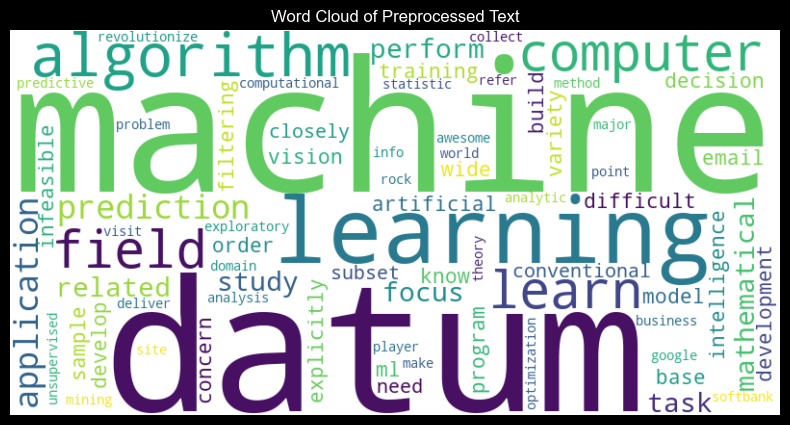

In [54]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Use the lemmatized tokens after stop word removal for the word cloud
# Join the list of tokens back into a single string

wordcloud_text = " ".join(spacy_lemmatized_tokens) # Using spaCy lemmatized tokens

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(wordcloud_text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Preprocessed Text")
plt.show()